# 🐍 Jour 4 — Fonctions avancées et graphiques

## 🎯 Ce que tu vas apprendre
1. **`enumerate`** et **`zip`** : boucler intelligemment
2. Les **décorateurs** : envelopper une fonction pour l'enrichir
3. L'opérateur **walrus** `:=`
4. **Matplotlib** : courbes, barres, heatmaps — tes premiers vrais graphiques

## 1. `enumerate` et `zip` : les deux compagnons du `for`

Deux situations ultra-courantes en bouclant :
1. « J'ai besoin de l'élément ET de son numéro » → **`enumerate`**
2. « J'ai DEUX listes parallèles à parcourir ensemble » → **`zip`**

```python
for position, name in enumerate(racers, start=1):   # (index, élément)
for name, time in zip(racers, lap_times):           # (élém. liste1, élém. liste2)
```
- `enumerate(liste, start=1)` fournit des paires `(numéro, élément)` — `start=1` fait commencer le compte à 1 au lieu de 0 (pratique pour un classement !).
- `zip(l1, l2)` avance dans les deux listes EN MÊME TEMPS, comme une fermeture éclair 🤐. (Si les listes n'ont pas la même taille, zip s'arrête à la plus courte.)

**⭐ Anti-pattern à bannir :** `for i in range(len(liste)): liste[i]...` — enumerate/zip font mieux et plus lisible.

### 🔍 Démo course automobile
- **enumerate** avec `start=1` → « Rank 1: Alice, Rank 2: Bob… » (sans start, Alice serait « Rank 0 » — bizarre pour un podium !)
- **zip** apparie les deux listes parallèles : Alice↔1m24s, Bob↔1m28s… Chaque tour de boucle reçoit UN COUPLE dépaqueté en `name, time` (le dépaquetage de tuples du Jour 2 !).

In [11]:
# Setup Data
racers = ["Alice", "Bob", "Charlie", "Diana"]
lap_times = ["1m 24s", "1m 28s", "1m 31s", "1m 22s"]

# 1. Using enumerate() to track positions
print("🏎️ --- Tournament Leaderboard ---")
# Pro-tip: 'start=1' changes our index from starting at 0 to starting at 1!
for position, name in enumerate(racers, start=1):
    print(f"Rank {position}: {name}")

print("\n📦 --- Pairing Data with zip() ---")
# zip() combines elements of parallel lists into pairs on the fly
for name, time in zip(racers, lap_times):
    print(f"Driver {name} clocked a lap time of {time}.")

🏎️ --- Tournament Leaderboard ---
Rank 1: Alice
Rank 2: Bob
Rank 3: Charlie
Rank 4: Diana

📦 --- Pairing Data with zip() ---
Driver Alice clocked a lap time of 1m 24s.
Driver Bob clocked a lap time of 1m 28s.
Driver Charlie clocked a lap time of 1m 31s.
Driver Diana clocked a lap time of 1m 22s.


### 📝 EXERCICE — Le menu du café ☕

**Énoncé (traduit) :** avec `zip()`, combine la liste des produits et celle des prix pour construire le dictionnaire `menu_dict` : `{'Espresso': 3.5, 'Latte': 4.5, ...}`.

⚠️ **La solution ci-dessous marche… une fois. Lis la note qui la suit pour comprendre son piège caché !**

### 🔴 La note promise — le piège du nom réutilisé

La solution MARCHE (le dict attendu est bien construit ✅)… mais regarde la variable de boucle :
```python
for items, prices in zip(products, prices):
```
La variable de boucle s'appelle **`prices`** — le MÊME nom que la liste ! À chaque tour, le nom `prices` est ÉCRASÉ par un prix isolé (3.50, puis 4.50…). Après la boucle, la liste `prices` n'existe plus — remplacée par le dernier float (3.25).

**Conséquence sournoise :** ré-exécute la cellule → `zip(products, 3.25)` → `TypeError` ! Un code qui ne marche qu'UNE fois est un code cassé (encore le coup du kernel !). **La correction :** des noms distincts au singulier : `for product, price in zip(products, prices):` — règle d'or : variable de boucle au SINGULIER, liste au PLURIEL.

In [12]:
products = ["Espresso", "Latte", "Croissant", "Muffin"]
prices = [3.50, 4.50, 3.75, 3.25]

# 1. Create your dictionary using zip()
menu_dict = {}
# TODO: Fill in menu_dict
for items, prices in zip(products, prices):
    menu_dict[items] = prices
    
# 2. Print the dictionary to verify
print(menu_dict)
# Expected Output: {'Espresso': 3.5, 'Latte': 4.5, 'Croissant': 3.75, 'Muffin': 3.25}

{'Espresso': 3.5, 'Latte': 4.5, 'Croissant': 3.75, 'Muffin': 3.25}


## 2. Les DÉCORATEURS

Un **décorateur** = une fonction qui PREND une fonction, l'ENVELOPPE de comportements supplémentaires, et RENVOIE la version enrichie — sans toucher au code original.

**L'analogie :** une coque de téléphone 📱 : le téléphone (ta fonction) reste identique, la coque (le décorateur) ajoute des fonctionnalités autour (protection, béquille…).

**L'anatomie (repère ces 3 étages dans la démo) :**
```python
def mon_decorateur(fonction_originale):          # 1. reçoit la fonction
    def wrapper(*args, **kwargs):                # 2. l'enveloppe
        # ... code AVANT ...
        resultat = fonction_originale(*args, **kwargs)   # appel de l'originale
        # ... code APRÈS ...
        return resultat                          # ⚠️ ne pas oublier !
    return wrapper                               # 3. renvoie l'enveloppe

@mon_decorateur                                   # ← le « sucre syntaxique »
def ma_fonction(): ...
```
Le `@mon_decorateur` au-dessus d'une `def` équivaut à `ma_fonction = mon_decorateur(ma_fonction)`. Remarque le retour des acquis : le wrapper utilise `*args, **kwargs` (Jour 3 !) pour transmettre N'IMPORTE QUELS arguments, et tout repose sur les closures (Jour 2 !).

### 🔍 Démo chronomètre — suis le trajet d'un appel :
1. `@calculate_execution_time` a remplacé `heavy_calculation` par son wrapper.
2. Appel → le wrapper note `start_time` → exécute la VRAIE fonction (la boucle des 10 millions) → note `end_time` → affiche la durée (~0.23 s) → **retourne le résultat** (sans ce `return`, `grand_total` vaudrait None !).
3. `original_function.__name__` récupère le nom (« heavy_calculation ») pour l'afficher — le décorateur est GÉNÉRIQUE, il fonctionnerait sur n'importe quelle fonction.
💡 Détail : ici on utilise `time.time()` — pour des mesures précises, `time.perf_counter()` (Jour 1) est préférable.

In [13]:
import time

# 1. Define the timing decorator
def calculate_execution_time(original_function):
    def wrapper_action(*args, **kwargs):
        # Record the time right before the function runs
        start_time = time.time()
        
        # Execute the actual function
        result = original_function(*args, **kwargs)
        
        # Record the time right after the function finishes
        end_time = time.time()
        
        # Calculate total duration
        duration = end_time - start_time
        print(f"⏱️ [Performance Summary]: '{original_function.__name__}' took {duration:.6f} seconds to complete.")
        
        # Return the result of the original function execution
        return result
        
    return wrapper_action


# 2. Applying the timer to a heavy computation function
@calculate_execution_time
def heavy_calculation(number_to_count_to):
    print(f"🧮 Simulating calculations up to {number_to_count_to:,}...")
    total = 0
    for i in range(number_to_count_to):
        total += i
    return total


# --- Testing the Performance Timer ---
# Let's see how long it takes Python to loop 10 million times
grand_total = heavy_calculation(10_000_000)
print(f"Calculation Result: {grand_total:,}")

🧮 Simulating calculations up to 10,000,000...
⏱️ [Performance Summary]: 'heavy_calculation' took 0.228779 seconds to complete.
Calculation Result: 49,999,995,000,000


### 📝 EXERCICE — Le décorateur `@simple_logger`

**Énoncé (traduit) :** créer un décorateur qui affiche `[LOG]: Function 'nom' is starting...` AVANT d'exécuter la fonction décorée. Indice : le nom d'une fonction s'obtient avec `fonction.__name__`.

⚠️ La solution ci-dessous a un petit bug d'inattention — sauras-tu le voir avant de lire la note ?

### 🔴 Le bug d'inattention — trouvé ?

Le décorateur fonctionne, MAIS les DEUX prints disent `is starting...` ! Le second (après l'exécution) devait dire quelque chose comme `has finished`. C'est un copier-coller non ajusté — regarde la sortie : « starting… 💰 payé… starting… » — le log raconte n'importe quoi.

**⭐ Leçon :** les messages de log sont pour les HUMAINS ; un log faux est pire qu'aucun log (il induit en erreur). Relis toujours ce que tes prints racontent.

In [19]:
# Write your custom decorator here
def simple_logger(original_function):
    def wrapper_action(*args, **kwargs) :
        print(f"[LOG] Function {original_function.__name__} is starting...")
        result = original_function(*args,**kwargs)
        print(f"[LOG] Function {original_function.__name__} is starting...")
        return result
    return wrapper_action

# Apply your decorator below:
@simple_logger
def process_payment():
    print("💰 Payment processed successfully.")

# Test your decorated function:
process_payment()

# Expected Output:
# [LOG]: Function 'process_payment' is starting...
# 💰 Payment processed successfully.

[LOG] Function process_payment is starting...
💰 Payment processed successfully.
[LOG] Function process_payment is starting...


## 3. L'opérateur WALRUS `:=` (le morse 🦭)

En Python classique, affecter (`x = 5`) et utiliser (`x > 3`) sont deux étapes séparées. Le walrus les fusionne : **affecte ET renvoie la valeur d'un coup**.

**Son cas d'usage roi — les boucles de saisie :**
```python
# AVANT : la ligne input() est écrite DEUX fois (avant la boucle + dedans)
user_input = input("...")
while user_input != "quit":
    ...
    user_input = input("...")

# AVEC LE WALRUS : une seule fois !
while (user_input := input("...")) != "quit":
    ...
```
La saisie est affectée à `user_input` PUIS comparée à "quit", le tout dans la condition. Élégant — mais n'en abuse pas : hors de ce genre de motif, il peut nuire à la lisibilité.

### 🔍 Démo walrus : les deux versions font EXACTEMENT pareil — mais la version walrus n'écrit `input()` qu'une seule fois. La boucle affiche chaque saisie jusqu'à ce que l'utilisateur tape « quit ». (Regarde la sortie enregistrée : la conversation s'arrête quand « quit » est saisi… enfin presque — « quit  » avec des espaces n'a pas matché du premier coup ! Un `.strip()` sur la saisie l'aurait toléré 😉.)

In [20]:
# TRADITIONAL WAY
user_input = input("Enter something (or 'quit'): ")
while user_input != "quit":
    print(f"You typed: {user_input}")
    user_input = input("Enter something (or 'quit'): ")

# WALRUS OPERATOR
while (user_input := input("Enter something (or 'quit'): ")) != "quit":
    print(f"You typed: {user_input}")

You typed: hello
You typed: wsh
You typed: ma guele 
You typed: c'est comment mon gars 
You typed: 
You typed: quit 


## 4. MATPLOTLIB : la bibliothèque de graphiques de référence

**L'anatomie d'un graphique :**
1. la **Figure** : la toile/page blanche entière ;
2. les **Axes** : le graphique dessiné dessus (axes X/Y, courbes…).

**Les types de base et QUAND les utiliser :**
| Type | Fonction | Quand |
|---|---|---|
| Courbe | `plt.plot()` | évolutions/tendances (dans le temps…) |
| Barres | `plt.bar()` | comparer des CATÉGORIES |
| Nuage | `plt.scatter()` | relation entre 2 variables numériques |

**La recette standard (repère-la dans CHAQUE démo qui suit) :**
```python
plt.figure(figsize=(10, 5))     # 1. créer la toile (largeur, hauteur en pouces)
plt.plot(x, y, label="...")     # 2. dessiner les données
plt.title("...")                 # 3. TOUJOURS titrer
plt.xlabel("...") ; plt.ylabel("...")   #    et étiqueter les axes !
plt.grid(True) ; plt.legend()    # 4. grille + légende
plt.show()                       # 5. afficher
```
Un graphique sans titre ni étiquettes d'axes est ILLISIBLE pour les autres (et pour toi dans 2 semaines) — les étapes 3-4 ne sont pas optionnelles !

### 🔍 Démo 1 — Courbes de ventes, ligne par ligne
- `plt.figure(figsize=(10, 5))` → toile de 10×5 pouces.
- Deux `plt.plot(...)` successifs → les DEUX courbes s'empilent sur le même graphique (c'est le comportement par défaut, très pratique).
- Les options : `marker="o"`/`"s"` (points ronds/carrés sur les données), `linestyle="--"` (pointillés pour distinguer B), `label=` (le nom qui apparaîtra dans la légende), `linewidth=2` (épaisseur).
- `plt.grid(alpha=0.6)` → grille discrète (alpha = transparence) ; `plt.legend(loc="upper left")` → la légende, positionnée.

**🔍 Comment lire ce graphique :** produit A domine presque partout, mais regarde le CROISEMENT en mars — B passe brièvement devant. Les tendances : A accélère fort d'avril à mai puis fléchit ; B monte régulièrement. C'est ça, « lire » une courbe : chercher tendances, croisements et ruptures.

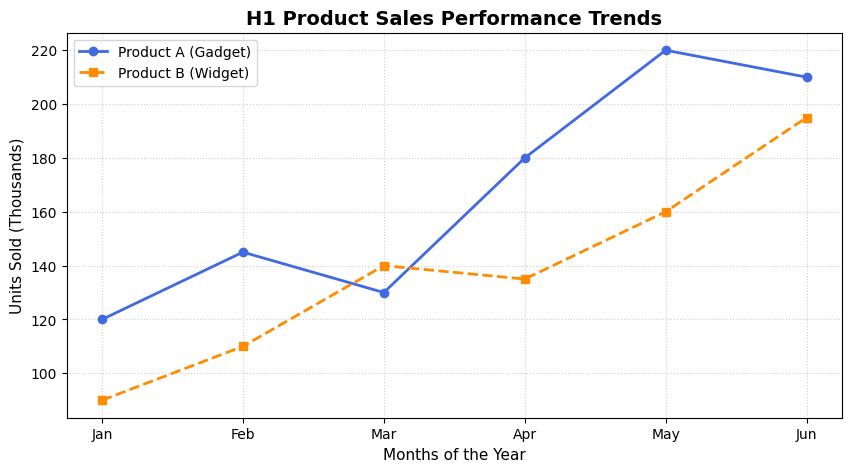

In [29]:
import matplotlib.pyplot as plt

# Data Setup (Imagine this came from an API or a database dictionary!)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
product_a_sales = [120, 145, 130, 180, 220, 210]
product_b_sales = [90, 110, 140, 135, 160, 195]

# 1. Initialize the Figure canvas and design its layout/size
plt.figure(figsize=(10, 5))

# 2. Plot data lines onto the canvas
# 'marker' adds points at the data intersections; 'linewidth' adjusts line thickness
plt.plot(months, product_a_sales, label="Product A (Gadget)", color="royalblue", marker="o", linewidth=2)
plt.plot(months, product_b_sales, label="Product B (Widget)", color="darkorange", marker="s", linewidth=2, linestyle="--")

# 3. Add Context and Labels (Crucial for presentation!)
plt.title("H1 Product Sales Performance Trends", fontsize=14, fontweight="bold")
plt.xlabel("Months of the Year", fontsize=11)
plt.ylabel("Units Sold (Thousands)", fontsize=11)

# 4. Add assistive structural elements
plt.grid(True, linestyle=":", alpha=0.6) # Adds a subtle background grid
plt.legend(loc="upper left")             # Displays the labels we defined in step 2

# 5. Render the plot on screen
plt.show()

### 🔍 Démo 2 — Diagramme en barres
`plt.bar(catégories, valeurs, color=[...])` — une barre par langage, chacune sa couleur (la liste de couleurs hexadécimales suit l'ordre des barres ; ce sont d'ailleurs les couleurs officielles de chaque langage 😄).

**Courbe vs barres — le bon choix :** ici les catégories (langages) n'ont AUCUN ordre naturel — les relier par une courbe suggérerait une continuité qui n'existe pas. Pour des catégories → BARRES, toujours.

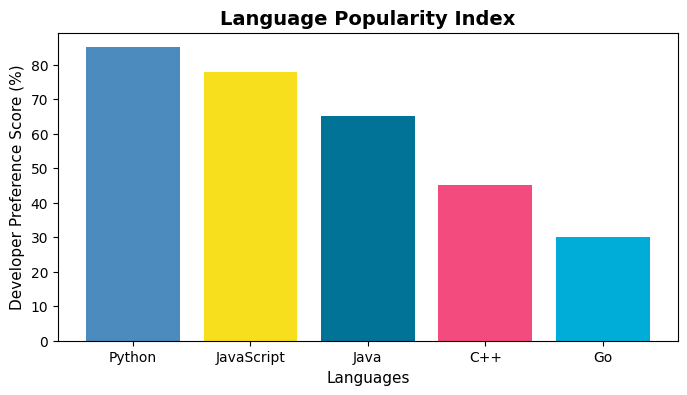

In [33]:
# Data Setup
programming_languages = ["Python", "JavaScript", "Java", "C++", "Go"]
popularity_score = [85, 78, 65, 45, 30]

# Initialize canvas
plt.figure(figsize=(8, 4))

# Create a bar chart
plt.bar(programming_languages, popularity_score, color=["#4B8BBE", "#F7DF1E", "#007396", "#F34B7D", "#00ADD8"])

# Add labels
plt.title("Language Popularity Index", fontsize=14, fontweight="bold")
plt.xlabel("Languages", fontsize=11)
plt.ylabel("Developer Preference Score (%)", fontsize=11)

# Display graph
plt.show()

### 🔍 Démo 3 — La heatmap (carte de chaleur)
- `foot_traffic` est une liste de listes = un tableau 2D (4 semaines × 5 jours).
- `plt.imshow(tableau, cmap="coolwarm")` → chaque case devient une COULEUR proportionnelle à sa valeur (bleu = froid/faible, rouge = chaud/élevé).
- `plt.colorbar(...)` → l'échelle de correspondance couleur↔valeur (indispensable, sinon les couleurs ne veulent rien dire !).
- `plt.xticks(ticks=range(5), labels=weekdays)` → remplace les indices 0-4 par les noms des jours.

**🔍 Comment lire une heatmap :** cherche les zones chaudes — la case la plus rouge = vendredi de la semaine 3 (30) : la semaine de vacances ! Et globalement, chaque ligne « chauffe » vers la droite : les vendredis attirent plus que les lundis. Une heatmap révèle les motifs d'un tableau de chiffres d'un seul regard.

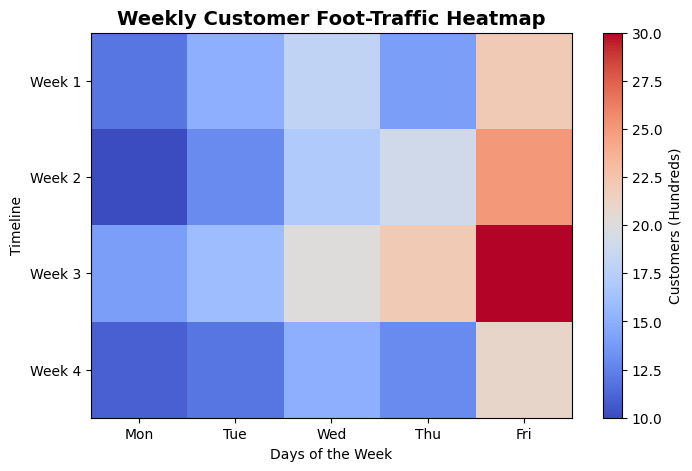

In [42]:
# 2D Data Array: 4 weeks (rows) x 5 weekdays (columns)
# Each row represents a week; each item is customer traffic
foot_traffic = [
    [12, 15, 18, 14, 22],  # Week 1
    [10, 13, 17, 19, 25],  # Week 2
    [14, 16, 20, 22, 30],  # Week 3 (A very busy holiday week!)
    [11, 12, 15, 13, 21]   # Week 4
]

weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri"]
weeks = ["Week 1", "Week 2", "Week 3", "Week 4"]

# Initialize canvas
plt.figure(figsize=(8, 5))

# Create the heatmap using the 'coolwarm' color palette
plt.imshow(foot_traffic, cmap="coolwarm")

# Add a colorbar legend to map colors to numbers
plt.colorbar(label="Customers (Hundreds)")

# Map our custom text labels to the grid ticks
plt.xticks(ticks=range(5), labels=weekdays)
plt.yticks(ticks=range(4), labels=weeks)

# Add titles and context
plt.title("Weekly Customer Foot-Traffic Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Days of the Week")
plt.ylabel("Timeline")

# Show the plot
plt.show()

### 📝 EXERCICE FINAL — Le réseau électrique renouvelable ⚡

**Énoncé (traduit) :** construire UN graphique comparant la production **solaire** et **éolienne** sur 6 heures :
1. toile `figsize=(10, 5)` ;
2. courbe Solar (couleur or/orange, marqueurs ronds `o`) + courbe Wind (couleur teal/bleu, marqueurs carrés `s`) sur le MÊME graphique ;
3. titre « Renewable Power Grid Generation », axes « Time of Day » / « Power Yield (kW) » ;
4. grille + légende.

**🔍 Comment lire le résultat :** les deux courbes se CROISENT — le solaire monte vers midi (soleil au zénith) pendant que l'éolien faiblit. C'est exactement le genre d'histoire qu'un bon graphique raconte d'un coup d'œil : la complémentarité des deux sources !

**Solution commentée (correcte et complète ✅) :** la recette standard est respectée à la lettre — toile, 2 courbes avec labels/couleurs/marqueurs distincts, titre, axes, grille, légende. Deux petits plus de qualité : `linestyle="--"` sur l'éolien (distinction supplémentaire, utile si impression en noir et blanc) et `plt.tight_layout()` (ajuste les marges automatiquement — bonne habitude).

## 📝 Résumé du Jour 4
1. **enumerate**(liste, start=1) → (numéro, élément) ; **zip**(l1, l2) → paires parallèles.
2. **Décorateur** = fonction qui enveloppe une fonction ; anatomie : wrapper(*args, **kwargs) + return du résultat ; `@nom` = sucre syntaxique.
3. **Walrus `:=`** : affecter dans une condition (boucles de saisie).
4. **Matplotlib** : la recette figure→plot→titre/axes→grille/légende→show ; courbes = tendances, barres = catégories, heatmap = tableau 2D en couleurs.

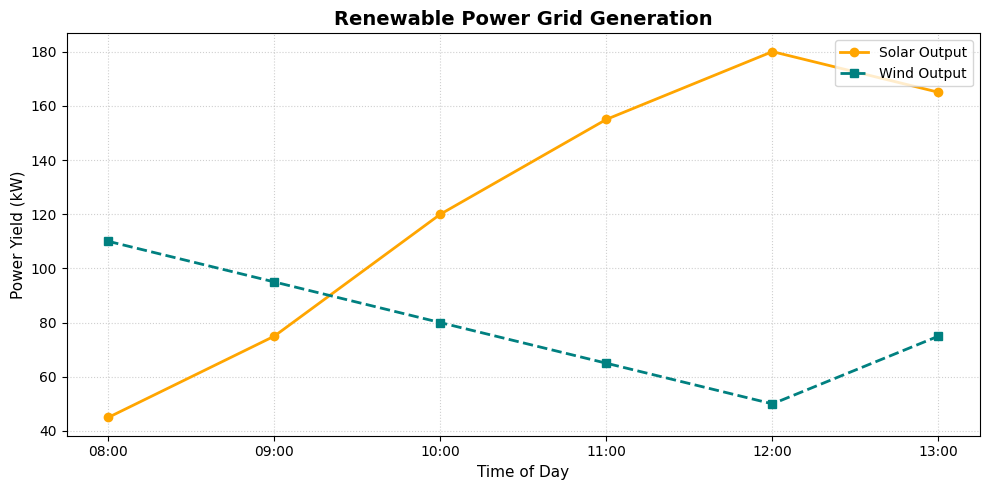

In [60]:
import matplotlib.pyplot as plt

grid_data = {
    "hours": ["08:00", "09:00", "10:00", "11:00", "12:00", "13:00"],
    "solar_kw": [45, 75, 120, 155, 180, 165],
    "wind_kw": [110, 95, 80, 65, 50, 75]
}

# 1. Le canevas
plt.figure(figsize=(10, 5))

# 2. Ligne Solar (couleur orange, marqueurs ronds "o")
plt.plot(grid_data["hours"], grid_data["solar_kw"],
         label="Solar Output", color="orange", marker="o", linewidth=2)

# 2. Ligne Wind (couleur teal, marqueurs carrés "s")
plt.plot(grid_data["hours"], grid_data["wind_kw"],
         label="Wind Output", color="teal", marker="s", linewidth=2, linestyle="--")

# 3. Titre, labels, grille et légende
plt.title("Renewable Power Grid Generation", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day", fontsize=11)
plt.ylabel("Power Yield (kW)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()